# Descriptive Anaylsis of the Sorption Dataset

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from preprocessing.utils import unify_doi
from training.train_utils import get_data, DataSettings, ModelSettings

plot_path = Path(os.getcwd()) / "plots" / "descriptive_analysis"
os.makedirs(plot_path, exist_ok=True)

raw_data, y_Kf, _ = get_data(
    DataSettings(0.85, True, 'all_vals', True, 'raw'),
    ModelSettings(None, 'raw', 'kf'),
    Path(os.getcwd()) / "data"
)

X_sorbat, y_n, _ = get_data(
    DataSettings(0.85, True, 'all_vals', True, 'raw'),
    ModelSettings(None, 'abrahams', 'n'),
    Path(os.getcwd()) / "data"
)
X_sorbat = X_sorbat.loc[:, [col for col in X_sorbat.columns if col.startswith('abrahams')]]
X_sorbat = X_sorbat.join(raw_data.loc[:, 'smiles'])

print(
    f"Data consists of {raw_data.shape[0]} rows",
    f"from {raw_data["doi"].apply(lambda doi: unify_doi(doi, short=True)).unique().shape[0]} publications",
    "of the following entities: ")
print(raw_data.columns)

Data consists of 234 rows from 20 publications of the following entities: 
Index(['doi', 'smiles', 'sorbat_name', 'ph', 'SLR (kg/L)', 'SSA (m^2/g)',
       'particle size', 'T', 'low conc_range (µg/L)', 'high conc_range (µg/L)',
       'salinity', 'cleaned_sorbent'],
      dtype='str')


## Range of Values in the Dataset / Table 1

In [4]:
citation_dict = {
    'https://doi.org/10.1016/j.chemosphere.2020.129133': r'\autocite{chenAdsorptionTetracyclinesPolyethylene2021}',
    'https://doi.org/10.1016/j.scitotenv.2022.160786': r'\autocite{liuMolecularLevelInsight2023}',
    'https://doi.org/10.1016/j.envpol.2019.113844': r'\autocite{sorensenSorptionPAHsMicroplastic2020}',
    'https://doi.org/10.1007/s11356-023-26390-x': r'\autocite{liangBehaviorMechanismsCiprofloxacin2023}',
    'https://doi.org/10.1016/j.chemosphere.2019.03.162': r'\autocite{liuHydrophobicSorptionBehaviors2019}',
    'https://doi.org/10.1016/j.envpol.2016.04.018': r'\autocite{hufferSorptionNonpolarOrganic2016}',
    'https://doi.org/10.1016/j.envpol.2023.122573': r'\autocite{frescuraInteractionFluoreneIts2023}',
    'https://doi.org/10.1016/j.ecoenv.2023.114533': r'\autocite{cuiSorptionRepresentativeOrganic2023}',
    'https://doi.org/10.1021/es405721v': r'\autocite{velzeboerStrongSorptionPCBs2014}',
    'https://doi.org/10.1007/s11356-019-04735-9': r'\autocite{wangSorptionBehaviorsPhenanthrene2019}'
}

tbl_lines = [
    r"\begin{table}[htp]",
    r"  \begin{center}",
    r"    {\renewcommand{\arraystretch}{1.25}%"
    r"    \begin{tabular}{c|c|c|c||c|c||c|c}",
    r"      & \multicolumn{3}{c||}{Matrix} & \multicolumn{2}{c||}{Sorbat} & \multicolumn{2}{c}{Sorbent}\\",
    r"      \hline",
    r"      & pH & T [°C] & SLR $\left[\frac{g}{L}\right]$ & "
    r"$C_{min}$ $\left[\frac{\mu g}{L}\right]$ & $C_{max}$ $\left[\frac{\mu g}{L}\right]$ &"
    r"SSA $\left[\frac{m^2}{g}\right]$ & particle size $[\mu m]$\\",
    r"      \hline \hline"
]
min_res, max_res = [], []
for col in ('ph', 'T', 'SLR (kg/L)', 'low conc_range (µg/L)', 'high conc_range (µg/L)', 'SSA (m^2/g)', 'particle size'):
    min_doi = raw_data.loc[raw_data[col] == raw_data[col].min(), 'doi'].unique()[0]
    max_doi = raw_data.loc[raw_data[col] == raw_data[col].max(), 'doi'].unique()[0]
    if col == 'SSA (m^2/g)':
        min_res.append(f"{raw_data[col].min():.2f}" + citation_dict[min_doi])
        max_res.append(f"{raw_data[col].max():.2f}" + citation_dict[max_doi])
    elif col == 'SLR (kg/L)':
        min_res.append(f"{(10**3)*raw_data[col].min():.3f}" + citation_dict[min_doi])
        max_res.append(f"{(10**3)*raw_data[col].max()}" + citation_dict[max_doi])
    else:
        min_res.append(f"{raw_data[col].min()}" + citation_dict[min_doi])
        max_res.append(f"{raw_data[col].max()}" + citation_dict[max_doi])
tbl_lines.append(f"      min & {min_res[0]} & {min_res[1]} & {min_res[2]} & {min_res[3]} & {min_res[4]} & {min_res[5]} & {min_res[6]}" + r" \\")
tbl_lines.append(f"      max & {max_res[0]} & {max_res[1]} & {max_res[2]} & {max_res[3]} & {max_res[4]} & {max_res[5]} & {max_res[6]}" + r" \\")
tbl_lines.append(r"    \end{tabular}")
tbl_lines.append(r"    }")
tbl_lines.append(r"  \end{center}")
tbl_lines.append(r"\end{table}")

print("\n".join(tbl_lines))

\begin{table}[htp]
  \begin{center}
    {\renewcommand{\arraystretch}{1.25}%    \begin{tabular}{c|c|c|c||c|c||c|c}
      & \multicolumn{3}{c||}{Matrix} & \multicolumn{2}{c||}{Sorbat} & \multicolumn{2}{c}{Sorbent}\\
      \hline
      & pH & T [°C] & SLR $\left[\frac{g}{L}\right]$ & $C_{min}$ $\left[\frac{\mu g}{L}\right]$ & $C_{max}$ $\left[\frac{\mu g}{L}\right]$ &SSA $\left[\frac{m^2}{g}\right]$ & particle size $[\mu m]$\\
      \hline \hline
      min & 5.0\autocite{chenAdsorptionTetracyclinesPolyethylene2021} & 10.0\autocite{sorensenSorptionPAHsMicroplastic2020} & 0.015\autocite{sorensenSorptionPAHsMicroplastic2020} & 0.0826\autocite{hufferSorptionNonpolarOrganic2016} & 4.0\autocite{cuiSorptionRepresentativeOrganic2023} & 0.01\autocite{cuiSorptionRepresentativeOrganic2023} & 2.0\autocite{wangSorptionBehaviorsPhenanthrene2019} \\
      max & 8.2\autocite{liuMolecularLevelInsight2023} & 35.0\autocite{liangBehaviorMechanismsCiprofloxacin2023} & 25.0\autocite{liuHydrophobicSorptionBeha

## Plots and Tables in Supplemental Material S8

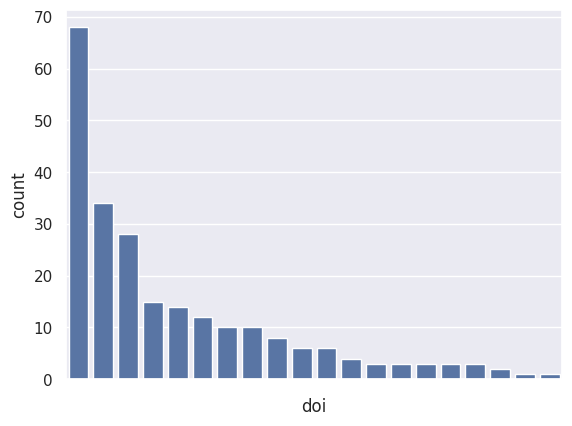

pH: mean: 7.4423076923076925, median: 7.0, iqr: 1.0999999999999996
temperature: mean: 23.67094017094017, median: 25.0, iqr: 0.0
SLR: mean: -7.190240349888371, median: -7.824046010856292, iqr: 1.4271163556401056
salinity: mean: 15.52282051282051, median: 1.0, iqr: 34.9


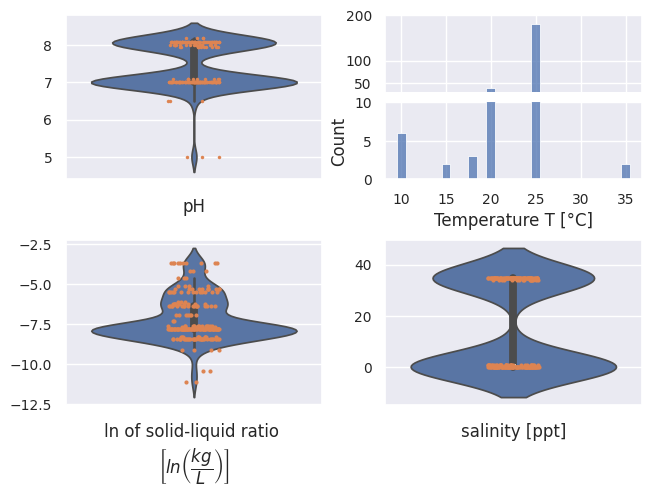

Lower concentration range: mean: 0.471353896685183, median: -0.23913029972822625, iqr: 1.7958800173440754


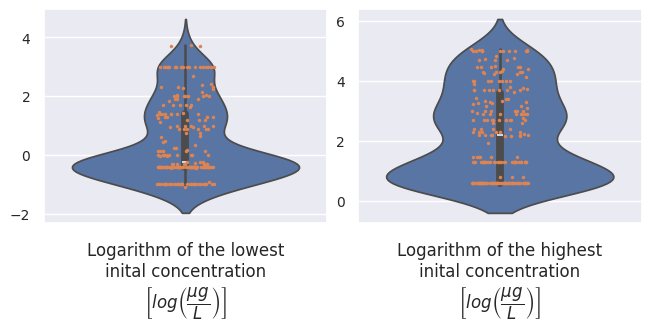

Upper concentration range: mean: 2.257070324684383, median: 2.2013971243204513, iqr: 2.9870971789144027
64


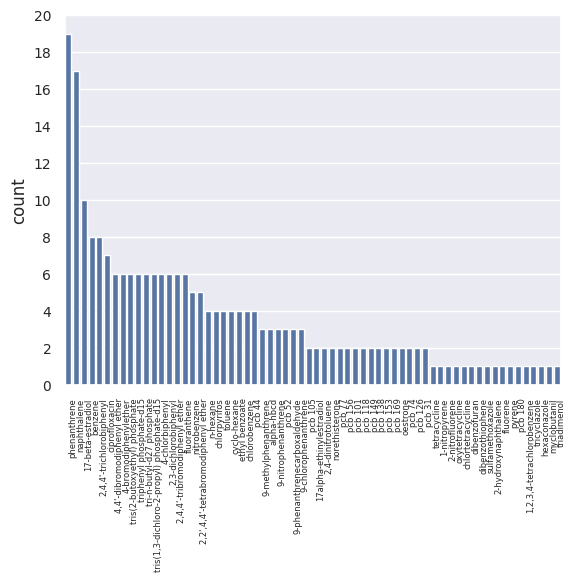

8


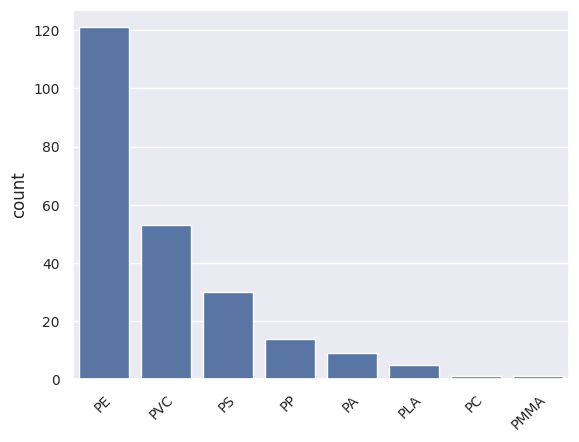

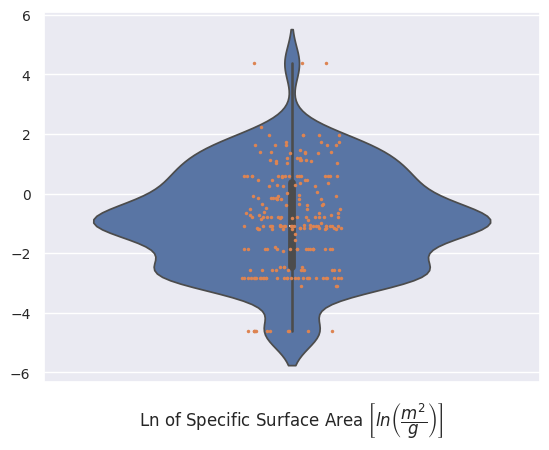

BET: mean: -0.9218148766829299, median: -1.0744172465940633, iqr: 2.806640896858714
Freundlich n: mean: 0.9296435037263522, median: 0.9, iqr: 0.39937500000000004
Freundlich Kf: mean: 4.043651536314203, median: 3.6431669359178818, iqr: 2.0933424725325542


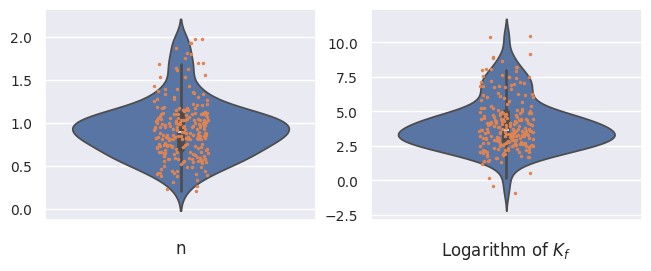

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import iqr

from preprocessing.utils import unify_doi

# Apply the default theme
sns.set_theme()

# dois
dois = raw_data["doi"].apply(lambda doi: unify_doi(doi, short=True))
ax = sns.countplot(x=dois, order=dois.value_counts().index, orient='x')
ax.set_xticklabels([])
plt.savefig(plot_path / "doi_count.pdf", dpi=1200, bbox_inches = "tight")
plt.show()


# Matrix properties
# broken axis in subplots adapted from https://stackoverflow.com/a/44731621
# copyright cc-by-sa ImportanceOfbeingErnest
plt.subplots(2,2, layout='constrained')
sns.violinplot(raw_data["ph"], ax=plt.subplot(221))
sns.stripplot(raw_data["ph"], ax=plt.subplot(221), s=2.5)
plt.subplot(221).set_ylabel("")
plt.subplot(221).set_xlabel("pH")
plt.subplot(221).tick_params(axis='y', labelsize='small')
print(f"pH: mean: {raw_data["ph"].mean()}, median: {raw_data["ph"].median()}, iqr: {iqr(raw_data["ph"])}")

divider = make_axes_locatable(plt.subplot(222))
ax2 = divider.new_vertical(size="100%", pad=0.1)
plt.gcf().add_axes(ax2)
sns.histplot(raw_data["T"], discrete=True, ax=ax2)
plt.subplot(222).set_xlabel("Temperature T [°C]")
plt.subplot(222).set_ylabel("")
plt.subplot(222).tick_params(axis='both', labelsize='small')
plt.subplot(222).set_ylim(0, 10)
plt.subplot(222).spines['top'].set_visible(False)
ax2.set_ylim(30, 200)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.tick_params(axis='both', labelsize='small', labelbottom=False)
ax2.set_yticks([50,100,200])
ax2.spines['bottom'].set_visible(False)
sns.histplot(raw_data["T"], discrete=True, ax=plt.subplot(222))
print(f"temperature: mean: {raw_data["T"].mean()}, median: {raw_data["T"].median()}, iqr: {iqr(raw_data["T"])}")


sns.violinplot(np.log(raw_data["SLR (kg/L)"]), ax=plt.subplot(223))
sns.stripplot(np.log(raw_data["SLR (kg/L)"]), ax=plt.subplot(223), s=3)
plt.subplot(223).set_ylabel("")
plt.subplot(223).set_xlabel("ln of solid-liquid ratio \n" + r"$\left[ln\left(\dfrac{kg}{L}\right)\right]$")
plt.subplot(223).tick_params(axis='y', labelsize='small')
print(f"SLR: mean: {np.log(raw_data["SLR (kg/L)"]).mean()}, median: {np.median(np.log(raw_data["SLR (kg/L)"]))}, iqr: {iqr(np.log(raw_data["SLR (kg/L)"]))}")

raw_data.loc[raw_data['salinity'].isna(), 'salinity'] = 0.1
sns.violinplot(raw_data['salinity'], ax=plt.subplot(224))
sns.stripplot(raw_data['salinity'], ax=plt.subplot(224), s=3)
plt.subplot(224).set_xlabel("salinity [ppt]")
plt.subplot(224).set_ylabel("")
plt.subplot(224).tick_params(axis='y', labelsize='small')
plt.savefig(plot_path / "matrix.pdf", dpi=1200, bbox_inches = "tight")
print(f"salinity: mean: {raw_data["salinity"].mean()}, median: {raw_data["salinity"].median()}, iqr: {iqr(raw_data["salinity"])}")
plt.show()

# Concentration range
plt.subplots(1, 2, layout='constrained', figsize=(6.4, 3.2))
sns.violinplot(np.log10(raw_data["low conc_range (µg/L)"]), ax=plt.subplot(121))
sns.stripplot(np.log10(raw_data["low conc_range (µg/L)"]), ax=plt.subplot(121), s=2.5)
plt.subplot(121).set_ylabel("")
plt.subplot(121).set_xlabel("Logarithm of the lowest\ninital concentration\n" + r"$\left[log\left(\dfrac{µg}{L}\right)\right]$")
plt.subplot(121).tick_params(axis='y', labelsize='small')

sns.violinplot(np.log10(raw_data["high conc_range (µg/L)"]), ax=plt.subplot(122))
sns.stripplot(np.log10(raw_data["high conc_range (µg/L)"]), ax=plt.subplot(122), s=2.5)
plt.subplot(122).set_ylabel("")
plt.subplot(122).set_xlabel("Logarithm of the highest\ninital concentration\n" + r"$\left[log\left(\dfrac{µg}{L}\right)\right]$")
plt.subplot(122).tick_params(axis='y', labelsize='small')
plt.savefig(plot_path / "crange.pdf", dpi=1200, bbox_inches = "tight")
plt.show()
print(f"Lower concentration range: mean: {np.log10(raw_data["low conc_range (µg/L)"]).mean()}, median: {np.median(np.log10(raw_data["low conc_range (µg/L)"]))}, iqr: {iqr(np.log10(raw_data["low conc_range (µg/L)"]))}")
print(f"Upper concentration range: mean: {np.log10(raw_data["high conc_range (µg/L)"]).mean()}, median: {np.median(np.log10(raw_data["high conc_range (µg/L)"]))}, iqr: {iqr(np.log10(raw_data["high conc_range (µg/L)"]))}")


# Smiles
sorbat = raw_data["sorbat_name"].apply(str.lower)
print("Sorbat count:", len(sorbat.unique()))
sns.countplot(x=sorbat, order=sorbat.value_counts().index, orient='x')
ax = plt.gca()
ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize='small')
ax.set_yticks(np.arange(0,22,2))
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")
plt.savefig(plot_path / "sorbat_names.pdf", dpi=1200, bbox_inches = "tight")
plt.show()

# Sorbents

sorbent = raw_data['cleaned_sorbent']
print("Sorbent count:", len(sorbent.unique()))
sns.countplot(x=sorbent, order=sorbent.value_counts().index, orient='x')
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.gca().tick_params(axis='both', labelsize='small')
plt.gca().set_xlabel("")
plt.savefig(plot_path / "sorbent_names.pdf", dpi=1200, bbox_inches = "tight")
plt.show()

# BET
sns.violinplot(np.log(raw_data["SSA (m^2/g)"]))
sns.stripplot(np.log(raw_data["SSA (m^2/g)"]), s=2.5)
plt.gca().tick_params(axis='both', labelsize='small')
plt.gca().set_ylabel("")
plt.gca().set_xlabel(r"Ln of Specific Surface Area $\left[ln\left(\dfrac{m^2}{g}\right)\right]$")
plt.savefig(plot_path / "bet.pdf", dpi=1200)
plt.show()
print(f"BET: mean: {np.log(raw_data["SSA (m^2/g)"]).mean()}, median: {np.median(np.log(raw_data["SSA (m^2/g)"]))}, iqr: {iqr(np.log(raw_data["SSA (m^2/g)"]))}")


# freundlich parameters
plt.subplots(1, 2, layout='constrained', figsize=(6.4, 2.6))
sns.violinplot(y_n, ax=plt.subplot(121))
sns.stripplot(y_n, ax=plt.subplot(121), s=2.5)
plt.subplot(121).set_ylabel("")
plt.subplot(121).set_xlabel("n")
plt.subplot(121).tick_params(axis='y', labelsize='small')
print(f"Freundlich n: mean: {y_n.mean()}, median: {np.median(y_n)}, iqr: {iqr(y_n)}")


sns.violinplot(y_Kf, ax=plt.subplot(122))
sns.stripplot(y_Kf, ax=plt.subplot(122), s=2.5)
plt.subplot(122).set_ylabel("")
plt.subplot(122).set_xlabel(r"Logarithm of $K_f$")
plt.subplot(122).tick_params(axis='y', labelsize='small')
plt.savefig(plot_path / "freundlich.pdf", dpi=1200, bbox_inches = "tight")
print(f"Freundlich Kf: mean: {y_Kf.mean()}, median: {np.median(y_Kf)}, iqr: {iqr(y_Kf)}")

## Table with sorbate properties / Table S8

In [41]:
from functools import cache
import time

import pubchempy as pcp

@cache
def get_logp(sm):
    logP = pcp.get_compounds(sm, 'smiles')[0].xlogp
    time.sleep(0.2)
    return logP

In [ ]:
csv_path = Path(os.getcwd()) / "data" / "raw_hyplast_w_smiles.csv"
raw_sorbat_data = pd.read_csv(csv_path).loc[:, ['smiles', 'molecular weight','solubility (mg/L)']].drop_duplicates()
assert len(raw_sorbat_data['smiles'].unique()) == raw_sorbat_data.shape[0]
sorbat_names = raw_data.loc[:, ['sorbat_name', 'smiles']]
sorbat_names = sorbat_names.join(sorbat_names.groupby('smiles').count(), on='smiles', rsuffix='_count')
sorbat_names = sorbat_names.join(X_sorbat.drop_duplicates().set_index('smiles'), on='smiles')
sorbat_names = sorbat_names.join(raw_sorbat_data.set_index('smiles'), on='smiles')
sorbat_names = sorbat_names.drop_duplicates().sort_values(by='sorbat_name_count', ascending=False)
sorbat_names.columns = ['name', 'smiles', 'count', 'E', 'S', 'A', 'B', 'V', 'L', 'mW', 'sol']
sorbat_names['logP'] = sorbat_names['smiles'].apply(get_logp)

tbl_lines = [
    r"\begin{center}",
    # r"    {\renewcommand{\arraystretch}{1.25}%"
    # r"    \begin{longtable}{X[l]||X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]|X[c]}",
    # r"      name & smiles & Mw & log Kow & solubility $\left[\dfrac{mg}{L}\right]$ & E & S & A & B & V & L & n\\",
    # r"    \begin{longtblr}{X[l]||X[c]|X[c]|X[c]|X[c]|X[c]}",
    # r"      name & smiles & Mw & log Kow & solubility $\left[\dfrac{mg}{L}\right]$ & n\\",
    r"  \begin{longtblr}{colspec={l||X[c]|X[c]|X[c]|X[c]}, rowhead=1, column{1-5}={fg=blue}, caption={}}",
    r"    name & Mw & log Kow & solubility $\left[\dfrac{mg}{L}\right]$ & n\\",
    r"    \hline",
]
for row in sorbat_names.itertuples(index=False):
    # tbl_lines.append(f"      {row.name} & {row.smiles} & {row.mW} & {row.logP} & {row.sol} & {row.E} & {row.S} & {row.A} & {row.B} & {row.V} & {row.L} & {row.count}" + r" \\")
    # tbl_lines.append(f"      {row.name} & {row.smiles} & {row.mW} & {row.logP} & {row.sol} & {row.count}" + r" \\")
    tbl_lines.append(f"    {row.name} & {row.mW} & {row.logP} & {row.sol} & {row.count}" + r" \\")
    # break
tbl_lines.append(r"  \end{longtblr}")
tbl_lines.append(r"\end{center}")

print("\n".join(tbl_lines))

\begin{center}
  \begin{longtblr}{colspec={X[l]||X[c]|X[c]|X[c]|X[c]}, rowhead=1}
    name & Mw & log Kow & solubility $\left[\dfrac{mg}{L}\right]$ & n\\
    \hline
    phenanthrene & 178.23 & 4.5 & 1.12 & 19 \\
    naphthalene & 128.17 & 3.3 & 32.0 & 17 \\
    17-beta-estradiol & 272.4 & 4.0 & 8.6 & 10 \\
    benzene & 78.11 & 2.1 & 1790.0 & 8 \\
    2,4,4'-trichlorobiphenyl & 257.5 & 5.6 & 0.1232472487730793 & 8 \\
    ciprofloxacin & 331.34 & -1.1 & 35000.0 & 7 \\
    4,4'-dibromodiphenyl ether & 328.0 & 4.1 & 1.2186355514387268 & 6 \\
    4-bromodiphenylether & 249.1 & 4.4 & 5.839473978961927 & 6 \\
    tris(2-butoxyethyl) phosphate & 398.5 & 2.8 & 1100.0 & 6 \\
    triphenyl phosphate-d15 & 326.3 & 4.6 & 34.16780452290086 & 6 \\
    tri-n-butyl-d27 phosphate & 266.31 & 2.9 & 1885.330418393398 & 6 \\
    tris(1,3-dichloro-2-propyl) phosphate-d15 & 430.9 & 3.3 & 90.02777027850053 & 6 \\
    4-chlorbiphenyl & 188.65 & 4.6 & 2.726822127512193 & 6 \\
    2,3-dichlorobiphenyl & 223.09 &